## Ablation Study

In [2]:
scale_ml = 1016/6039 * 100
scale_st = 2940/25390 * 100
scale_fo = 3420/16644 * 100

In [3]:
import numpy as np

np.array([0.3130, 0.5890, 0.3341, 0.6625]) * scale_fo

array([ 6.43150685, 12.10273973,  6.86506849, 13.6130137 ])

In [4]:
abaltion_results = {
    'ml-1m': {
        'original': {
            'ndcg@20': 4.39,
            'recall@20': 7.03,
            'ndcg@50': 5.10,
            'recall@50': 9.41
        },  
        '-rl': {
            'ndcg@20': 3.95,
            'recall@20': 6.17,
            'ndcg@50': 4.78,
            'recall@50': 8.91
        },  
        '-sft': {
            'ndcg@20': 3.56,
            'recall@20': 5.81,
            'ndcg@50': 4.28,
            'recall@50': 8.25
        },  
        '-sneck': {
            'ndcg@20': 4.10,
            'recall@20': 6.86,
            'ndcg@50': 4.96,
            'recall@50': 9.44
        },  
    },
    'steam': {
        'original': {
            'ndcg@20': 5.65,
            'recall@20': 8.80,
            'ndcg@50': 5.78,
            'recall@50': 9.30
        },  
        '-rl': {
            'ndcg@20': 5.44,
            'recall@20': 8.33,
            'ndcg@50': 5.55,
            'recall@50': 8.60
        },  
        '-sft': {
            'ndcg@20': 5.05,
            'recall@20': 8.28,
            'ndcg@50': 5.18,
            'recall@50': 8.73
        },  
        '-sneck': {
            'ndcg@20': 5.30,
            'recall@20': 8.27,
            'ndcg@50': 5.55,
            'recall@50': 9.06
        },  
    },
    'food': {
        'original': {
            'ndcg@20': 9.82,
            'recall@20': 13.16,
            'ndcg@50': 10.16,
            'recall@50': 14.35
        },  
        '-rl': {
            'ndcg@20': 9.40,
            'recall@20': 11.90,
            'ndcg@50': 9.70,
            'recall@50': 12.98
        },  
        '-sft': {
            'ndcg@20': 6.43,
            'recall@20': 12.10,
            'ndcg@50': 6.87,
            'recall@50': 13.61
        },  
        '-sneck': {
            'ndcg@20': 9.72,
            'recall@20': 12.93,
            'ndcg@50': 10.11,
            'recall@50': 14.30
        },  
    }
}

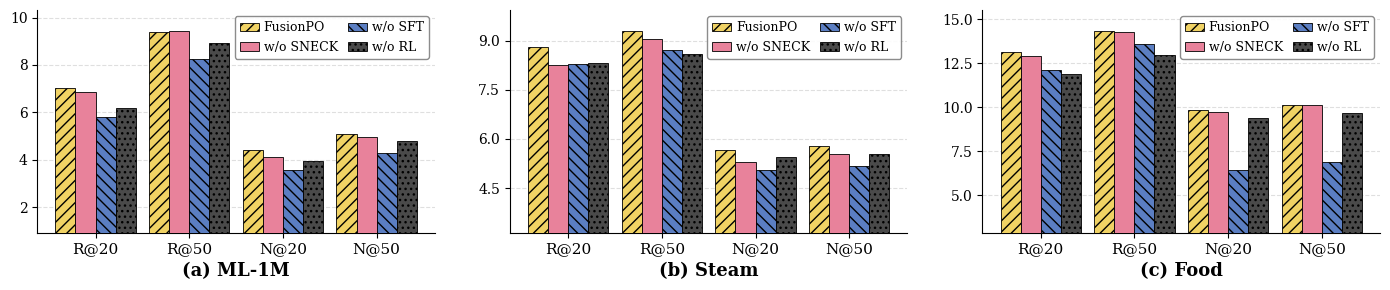

In [9]:
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['mathtext.fontset'] = 'stix'

datasets = ['ml-1m', 'steam', 'food']
dataset_labels = ['(a) ML-1M', '(b) Steam', '(c) Food']
metrics = ['recall@20', 'recall@50', 'ndcg@20', 'ndcg@50']
metric_labels = ['R@20', 'R@50', 'N@20', 'N@50']
variants = ['original', '-sneck', '-sft', '-rl']
variant_labels = ['FusionPO', 'w/o SNECK', 'w/o SFT', 'w/o RL']

colors = ['#F0D264', '#E8829B', '#5B7EC2', '#4A4A4A']
hatches = ['///', '', '\\\\\\', '...']
edgecolor = 'black'

fig, axes = plt.subplots(1, 3, figsize=(14, 3))

n_groups = len(metrics)
n_bars = len(variants)
bar_width = 0.18
group_gap = 0.12

for ax_idx, (ds, ds_label) in enumerate(zip(datasets, dataset_labels)):
    ax = axes[ax_idx]
    
    x = np.arange(n_groups) * (n_bars * bar_width + group_gap)
    
    for i, (var, var_label) in enumerate(zip(variants, variant_labels)):
        vals = [abaltion_results[ds][var][m] for m in metrics]
        bars = ax.bar(
            x + i * bar_width, vals, bar_width,
            label=var_label,
            color=colors[i],
            hatch=hatches[i],
            edgecolor=edgecolor,
            linewidth=0.6,
            zorder=3
        )
    
    ax.set_xticks(x + bar_width * (n_bars - 1) / 2)
    ax.set_xticklabels(metric_labels, fontsize=11)
    ax.set_xlabel(ds_label, fontsize=13, fontweight='bold')
    
    all_vals = [abaltion_results[ds][v][m] for v in variants for m in metrics]
    ymin = min(all_vals)
    ymax = max(all_vals)
    margin = (ymax - ymin) * 0.15
    ax.set_ylim(bottom=max(0, ymin - margin * 3), top=ymax + margin)

    ax.tick_params(axis='y', labelsize=10)
    ax.yaxis.set_major_locator(plt.MaxNLocator(6))
    ax.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)
    ax.set_axisbelow(True)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.legend(
        fontsize=9, ncol=2,
        loc='upper right',
        frameon=True, framealpha=0.9,
        edgecolor='gray',
        handlelength=1.5, handletextpad=0.4,
        columnspacing=0.8,
    )

plt.tight_layout(w_pad=2.5)
plt.savefig('ablation_study.pdf', dpi=300, bbox_inches='tight')
plt.savefig('ablation_study.png', dpi=300, bbox_inches='tight')
plt.show()